## Advanced Regressin Models - Polynomial Regression and Regularization

### Polynomial Regresssion (Non-Linear Relationships)

Polynomial regression is an extension of linear regression that models **non-linear relationships** by introducing higher-order terms of input features

#### Steps in Polynomial Regression
1. Feature Transformation
   - Create polynomial feature from the original input data
   - Example: x -> [x, x^2, x^3]
2. Model Training
   - Performs linear regression on the transformed features
3. Evaluations
   - Assess the model's ability to capture the data's non-linear structure

##### Advantages 
 - Capture non-linear relationships effectively
  
##### Limitations 
 - Prone to overfitting with high-degree polynomials
 - May require regularization to avoid overfitting

In [1]:
# Importing linraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [7]:
# Generate Synthetic Data
np.random.seed(42)
X = np.random.rand(100,1)*10
y = 3* X**2 + 2 * X + np.random.randn(100,1)*5
print(X)
print("-----------")
print(y)

[[3.74540119]
 [9.50714306]
 [7.31993942]
 [5.98658484]
 [1.5601864 ]
 [1.5599452 ]
 [0.58083612]
 [8.66176146]
 [6.01115012]
 [7.08072578]
 [0.20584494]
 [9.69909852]
 [8.32442641]
 [2.12339111]
 [1.81824967]
 [1.8340451 ]
 [3.04242243]
 [5.24756432]
 [4.31945019]
 [2.9122914 ]
 [6.11852895]
 [1.39493861]
 [2.92144649]
 [3.66361843]
 [4.56069984]
 [7.85175961]
 [1.99673782]
 [5.14234438]
 [5.92414569]
 [0.46450413]
 [6.07544852]
 [1.70524124]
 [0.65051593]
 [9.48885537]
 [9.65632033]
 [8.08397348]
 [3.04613769]
 [0.97672114]
 [6.84233027]
 [4.40152494]
 [1.22038235]
 [4.9517691 ]
 [0.34388521]
 [9.09320402]
 [2.58779982]
 [6.62522284]
 [3.11711076]
 [5.20068021]
 [5.46710279]
 [1.84854456]
 [9.69584628]
 [7.75132823]
 [9.39498942]
 [8.9482735 ]
 [5.97899979]
 [9.21874235]
 [0.88492502]
 [1.95982862]
 [0.45227289]
 [3.25330331]
 [3.8867729 ]
 [2.71349032]
 [8.28737509]
 [3.56753327]
 [2.8093451 ]
 [5.42696083]
 [1.40924225]
 [8.02196981]
 [0.74550644]
 [9.86886937]
 [7.72244769]
 [1.98

In [3]:
# Transfomr features to polynomial
poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)

In [8]:
# Fit Polynomial Regression 
model = LinearRegression()
model.fit(X_poly, y)
y_pred = model.predict(X_poly)
print(y_pred)

[[ 48.91419923]
 [290.54221704]
 [174.45496576]
 [118.31428491]
 [ 11.3892123 ]
 [ 11.386713  ]
 [  4.22941638]
 [242.13815917]
 [119.24841326]
 [163.56729669]
 [  3.07056429]
 [302.15352859]
 [224.06662992]
 [ 18.2139526 ]
 [ 14.27095447]
 [ 14.46081876]
 [ 33.59546127]
 [ 91.9705103 ]
 [ 63.70782766]
 [ 31.0975917 ]
 [123.3757913 ]
 [  9.76190526]
 [ 31.2698725 ]
 [ 46.973743  ]
 [ 70.53792291]
 [199.93825855]
 [ 16.50690979]
 [ 88.49656425]
 [115.95687909]
 [  3.77614249]
 [121.71125371]
 [ 12.95792905]
 [  4.54130559]
 [289.44798304]
 [299.54600612]
 [211.61815487]
 [ 33.66832547]
 [  6.40383827]
 [153.07167581]
 [ 65.99076092]
 [  8.22776943]
 [ 82.38018691]
 [  3.39522885]
 [266.28476076]
 [ 25.328672  ]
 [143.82145807]
 [ 35.07677699]
 [ 90.41405966]
 [ 99.44097911]
 [ 14.63647406]
 [301.95488916]
 [194.99086609]
 [283.86437062]
 [258.04401717]
 [118.02661274]
 [273.52867387]
 [  5.81265613]
 [ 16.02825721]
 [  3.73338512]
 [ 37.86742286]
 [ 52.36682963]
 [ 27.48537361]
 [222.12

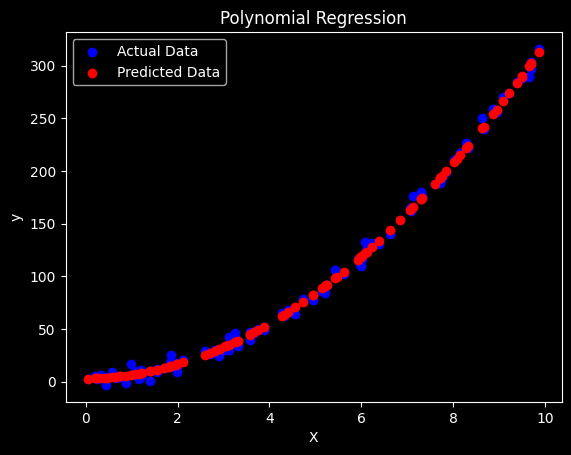

In [9]:
# Plot Results
plt.scatter(X, y, color="blue",label="Actual Data")
plt.scatter(X,y_pred, color="red",label="Predicted Data")
plt.title("Polynomial Regression")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

In [10]:
# Evaluating Model
mse = mean_squared_error(y, y_pred)
print("Mean Square Error (MSE):", mse)

Mean Square Error (MSE): 19.429841658755922


---

## Lasso and Ridge Regression
What is regularization
- Technique use to prevent overfitting by adding a penalty term to the cost function of the regression model
  

- #### Types of Regularization
  - Ridge Regression (L2 Regularization)
    - Adds the sum of the squared coefficients to the cost function 
    - Ridge shrinks cofficients but does not eliminate them
  
  - Lasso Regression (L1 Regulasization)
    - Adds the sum of absolute coefficients to the const function
    - Encourages sparsity in the coefficients, effectively performing feature selection
    - Lasso can shrink some coefficients to zero, removing irrelevant features

#### Avoding Overfitting with Regularization
- Regularization reduces the risk of overfitting by controlling the complexity of the model
- The regularization parameter λ also called alpha, in some libearies plas a critical role
- A high λ value increases the penality, forcing smaller coefficients and reducing overfitting
- A low λ value allows the model to fit the training data more closely, increasing the risk of overfitting